# XAI vs No XAI Comparison - Boltz-2 Binding Affinity (MGYP) — Extended with Baselines

Comparing the effect of explainable AI (XAI) guidance on molecule optimization performance using Boltz-2 binding affinity predictions for the MGYP protein target.

This extended version also includes REINVENT, GraphGA, and GP-BO baseline molecules scored with Boltz-2.

In [36]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import random

random.seed(42)
np.random.seed(42)

In [37]:
# Define paths
RUN_DIR = Path("../../data/runs")
BASELINE_CSV = Path("../../data/results/baseline_molecules_boltz2_pred.csv")
FIGURE_DIR = Path("./figures")

# Set to False to hide legend (for combined figures with shared legend)
SHOW_LEGEND = True

# MGYP protein target traces
MGYP_TRACES = [
    ("boltz2_binding_optimization_conversation_20260120_185114.json", {"intervention": "with_explanation", "repeat": 1}),
    ("boltz2_binding_optimization_conversation_20260120_164334.json", {"intervention": "no_explanation", "repeat": 1}),
    ("boltz2_binding_optimization_conversation_20260121_125157.json", {"intervention": "no_protein", "repeat": 1}),
    ("boltz2_binding_optimization_conversation_20260121_125339.json", {"intervention": "with_explanation", "repeat": 2}),
    ("boltz2_binding_optimization_conversation_20260121_130409.json", {"intervention": "no_explanation", "repeat": 2}),
    ("boltz2_binding_optimization_conversation_20260121_130058.json", {"intervention": "no_protein", "repeat": 2}),
    ("boltz2_binding_optimization_conversation_20260121_152419.json", {"intervention": "with_explanation", "repeat": 3}),
    ("boltz2_binding_optimization_conversation_20260121_153547.json", {"intervention": "no_explanation", "repeat": 3}),
    ("boltz2_binding_optimization_conversation_20260121_152832.json", {"intervention": "no_protein", "repeat": 3}),
    ("boltz2_binding_optimization_conversation_20260123_125515.json", {"intervention": "with_explanation", "repeat": 7}),
    ("boltz2_binding_optimization_conversation_20260123_131656.json", {"intervention": "no_explanation", "repeat": 7}),
    ("boltz2_binding_optimization_conversation_20260123_132736.json", {"intervention": "no_protein", "repeat": 7}),
    ("boltz2_binding_optimization_conversation_20260123_164046.json", {"intervention": "with_explanation", "repeat": 8}),
    ("boltz2_binding_optimization_conversation_20260123_163227.json", {"intervention": "no_explanation", "repeat": 8}),
    ("boltz2_binding_optimization_conversation_20260123_163719.json", {"intervention": "no_protein", "repeat": 8}),
]

# Intervention mapping for display names
INTERVENTION_MAP = {
    "with_explanation": "Full explanation",
    "no_explanation": "No explanation",
    "no_protein": "No protein",
}

## Loading Data

In [38]:
def load_trace(p: Path) -> dict:
    """Load conversation from JSON file."""
    with open(p) as f:
        return json.load(f)


def extract_iteration_score_table(conversation: dict, max_it: int = 49) -> pd.DataFrame:
    """Extract iteration and score from conversation trace."""
    trace = conversation.get("trace", [])
    
    if len(trace) == 0:
        return pd.DataFrame({
            "iteration": range(max_it),
            "score": [np.nan] * max_it,
        })
    
    df = pd.DataFrame(trace)
    
    # Use original_score if available, otherwise use score
    if "original_score" in df.columns:
        df = df[["iteration", "original_score"]].rename(columns={"original_score": "score"})
    else:
        df = df[["iteration", "score"]]
    
    # Fill missing iterations with NaN
    max_it = max(df["iteration"].max(), max_it)
    missing_its = set(range(1, max_it + 1)) - set(df["iteration"])
    
    if missing_its:
        missing_df = pd.DataFrame({
            "iteration": list(missing_its),
            "score": [np.nan] * len(missing_its),
        })
        df = pd.concat([df, missing_df], ignore_index=True)
    
    return df


def load_agent_traces(traces_list: list, run_dir: Path) -> pd.DataFrame:
    """Load all agent traces into a DataFrame."""
    dfs = []
    for fn, extra_cols in traces_list:
        conversation = load_trace(run_dir / fn)
        df = extract_iteration_score_table(conversation)
        for k, v in extra_cols.items():
            df[k] = v
        dfs.append(df)
    agent_df = pd.concat(dfs, ignore_index=True)
    agent_df["model"] = agent_df["intervention"].map(INTERVENTION_MAP)
    return agent_df


def load_baseline_csv(csv_path: Path) -> pd.DataFrame:
    """Load baseline molecules scored with Boltz-2 from CSV.
    
    The CSV has: model, replicate, iteration, smiles, affinity_probability_binary, affinity_pred_value
    We use affinity_probability_binary as the score (higher is better, matches agent score).
    """
    baseline_df = pd.read_csv(csv_path)
    baseline_df = baseline_df.rename(columns={"affinity_probability_binary": "score"})
    # Align columns with agent data
    baseline_df["intervention"] = baseline_df["model"]
    baseline_df["repeat"] = baseline_df["replicate"]
    return baseline_df[["model", "intervention", "repeat", "iteration", "score"]]


# Load agent traces
agent_df = load_agent_traces(MGYP_TRACES, RUN_DIR)

# Load baseline CSV
baseline_df = load_baseline_csv(BASELINE_CSV)

# Combine into single DataFrame
df = pd.concat(
    [agent_df[["model", "intervention", "repeat", "iteration", "score"]],
     baseline_df],
    ignore_index=True,
)

print(f"Total rows: {len(df)}")
print("Models:")
print(df.groupby("model")["repeat"].nunique())

Total rows: 1194
Models:
model
Full explanation    5
GP-BO               3
GraphGA             3
No explanation      5
No protein          5
REINVENT            3
Name: repeat, dtype: int64


---
## Best-so-far Progression Plot

> **Note on baselines:** With only 50 oracle calls, REINVENT / GraphGA / GP-BO never complete their initialization phase (default population sizes: GraphGA=120, GP-BO=340). These curves therefore represent **random sampling from a drug-like (ZINC) library** scored with Boltz-2, not actual algorithm optimization. Treat them as a random-search lower bound, not as representative of these algorithms' capabilities.

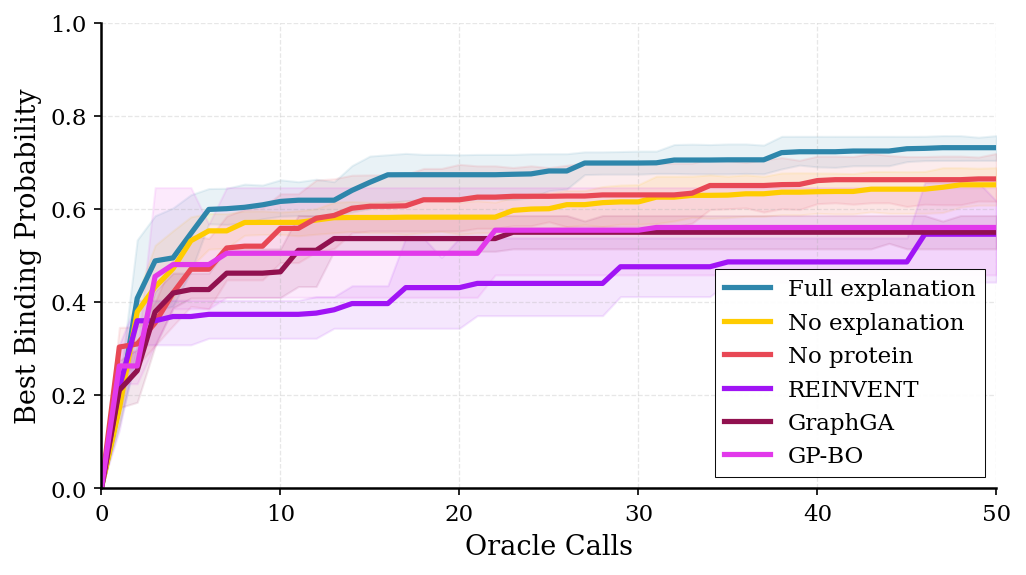

In [39]:
# Compute best-so-far (cummax) - for binding probability, higher is better
# First fill NaN with 0 so cummax works correctly (0 is worst for probability)
df["score_filled"] = df["score"].fillna(0.0)
df["best_so_far"] = (
    df.sort_values("iteration")
    .groupby(["model", "repeat"])["score_filled"]
    .cummax()
)

# Pivot so each run is a column, forward-fill to handle runs ending early
max_iter = 50
all_iterations = range(0, max_iter + 1)
df_plot = (
    df[df["iteration"] <= max_iter]
    .pivot_table(index="iteration", columns=["model", "repeat"], values="best_so_far")
    .reindex(all_iterations)
    .ffill()
    .fillna(0)  # Baseline at oracle call 0 (no score yet)
    .melt(ignore_index=False)
    .reset_index()
)

# Set publication-quality style
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.figsize': (6, 4),
    'axes.linewidth': 1.2,
    'grid.linewidth': 0.6,
    'lines.linewidth': 2.5,
})

# Create figure
fig, ax = plt.subplots(figsize=(7, 4), dpi=150)

# Define color palette
model_colors = {
    'Full explanation': '#2E86AB',
    'No explanation': '#ffcc00',
    'No protein': '#E84855',
    'REINVENT': '#A014F5',
    'GraphGA': "#91114F",
    'GP-BO': "#E239EB",
}

# Define legend order
legend_order = [
    'Full explanation',
    'No explanation',
    'No protein',
    'REINVENT',
    'GraphGA',
    'GP-BO',
]

legend_labels = {
    'Full explanation': 'Full explanation',
    'No explanation': 'No explanation',
    'No protein': 'No protein',
    'REINVENT': 'REINVENT',
    'GraphGA': 'GraphGA',
    'GP-BO': 'GP-BO',
}

# Plot with seaborn (mean + 95% bootstrap CI)
sns.lineplot(
    data=df_plot,
    x="iteration",
    y="value",
    hue="model",
    hue_order=legend_order,
    palette=model_colors,
    errorbar=('ci', 95),
    err_kws={'alpha': 0.1},
    linewidth=2.5,
    ax=ax
)

# Styling
ax.set_xlabel("Oracle Calls", fontsize=13, fontweight='normal')
ax.set_ylabel("Best Binding Probability", fontsize=13, fontweight='normal')
ax.set_xlim(0, 50)
ax.set_ylim(0, 1.0)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Conditionally show/hide legend
if SHOW_LEGEND:
    handles, labels = ax.get_legend_handles_labels()
    new_labels = [legend_labels.get(label, label) for label in labels]
    legend = ax.legend(
        handles,
        new_labels,
        frameon=True,
        fancybox=False,
        shadow=False,
        framealpha=0.95,
        edgecolor='black',
        loc='lower right'
    )
    legend.get_frame().set_linewidth(0.5)
else:
    ax.get_legend().remove()

plt.tight_layout()

# Save figure
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURE_DIR / 'xai_vs_no_xai_boltz2_mgyp_extended.pdf', format='pdf', bbox_inches='tight', dpi=300)

plt.show()

---
## AUC Top-1 over 50 Iterations

In [40]:
def bootstrap_ci(data, n_bootstrap=10000, ci=0.95):
    """Compute bootstrap 95% CI for the mean."""
    data = data.dropna()
    if len(data) < 2:
        return np.nan, np.nan
    result = stats.bootstrap(
        (data.values,),
        statistic=np.mean,
        n_resamples=n_bootstrap,
        confidence_level=ci,
        random_state=42
    )
    return result.confidence_interval.low, result.confidence_interval.high


def compute_auc_top1(group_df, max_oracle_calls=50):
    """Compute AUC of top-1 (best) score vs oracle calls from a dataframe group.
    
    Uses trapezoidal integration (same as PMO benchmark).
    
    Args:
        group_df: DataFrame with 'score' and 'iteration' columns for a single run
        max_oracle_calls: Maximum number of oracle calls (default 50)
    
    Returns:
        AUC value normalized to [0, 1]
    """
    sorted_df = group_df.sort_values('iteration')
    
    best_score = 0.0
    best_at_call = {}
    
    for _, row in sorted_df.iterrows():
        oracle_call = int(row['iteration'])
        score = float(row['score']) if not np.isnan(row['score']) else 0.0
        
        if oracle_call > max_oracle_calls:
            break
        
        if score > best_score:
            best_score = score
        
        best_at_call[oracle_call] = best_score
    
    if not best_at_call:
        return 0.0
    
    oracle_calls = sorted(best_at_call.keys())
    
    # Compute AUC using trapezoidal integration
    auc = 0.0
    prev_call = 0
    prev_best = 0.0
    
    for call in oracle_calls:
        auc += (call - prev_call) * (best_at_call[call] + prev_best) / 2
        prev_call = call
        prev_best = best_at_call[call]
    
    # Extend to max_oracle_calls with the last value
    auc += (max_oracle_calls - prev_call) * prev_best
    
    # Normalize by max_oracle_calls to get average best-so-far score
    return auc / max_oracle_calls


# Compute AUC Top-1 for each model/repeat
MAX_ORACLE_CALLS = 50

auc_records = []
for (model, repeat), group in df.groupby(['model', 'repeat']):
    auc = compute_auc_top1(group, MAX_ORACLE_CALLS)
    auc_records.append({
        'model': model,
        'repeat': repeat,
        'auc_top1': auc
    })

auc_df = pd.DataFrame(auc_records)

# Summarize by model with bootstrap CI
auc_summary_rows = []
for model, group in auc_df.groupby('model'):
    values = group['auc_top1']
    mean_val = values.mean()
    ci_low, ci_high = bootstrap_ci(values)
    ci_low_dist = mean_val - ci_low
    ci_high_dist = ci_high - mean_val
    auc_summary_rows.append({
        "Model": model,
        "Mean AUC Top-1": mean_val,
        "CI 95% -": ci_low_dist,
        "CI 95% +": ci_high_dist,
        "N": len(values),
    })

# Sort in legend order
auc_summary = (
    pd.DataFrame(auc_summary_rows)
    .set_index("Model")
    .reindex(legend_order)
    .round(3)
)

print(f"AUC Top-1 over {MAX_ORACLE_CALLS} iterations with 95% Bootstrap CI")
auc_summary

AUC Top-1 over 50 iterations with 95% Bootstrap CI


,Mean AUC Top-1,CI 95% -,CI 95% +,N
Model,,,,
Full explanation,0.650,0.028,0.030,5
No explanation,0.581,0.052,0.023,5
No protein,0.589,0.046,0.066,5
REINVENT,0.435,0.024,0.047,3
GraphGA,0.509,0.018,0.034,3
GP-BO,0.518,0.061,0.104,3
